# Demo for PresentImages timing
VR Dec 11, 2025

In [1]:
import retinanalysis as ra
import matplotlib.pyplot as plt
import numpy as np

C:\Users\Yasmine Tani\anaconda3\envs\retinanalysis\Lib\site-packages\datajoint\settings.py:992: UserWarning: No datajoint.json found. Using defaults and environment variables. Run `dj.config.save_template()` to create a template configuration.
  config = _create_config()


Find and load dataset

In [2]:
df = ra.get_datasets_from_protocol_names('presentimages')
df.tail()

[2026-07-28 16:07:17] DataJoint 2.2.2 connected to root@127.0.0.1:3306

Found 1 protocols matching "presentimages":
['manookinlab.protocols.PresentImages']

Found 1 experiments, 3 epoch blocks.



,exp_name,datafile_name,NDF,chunk_name,protocol_name,is_mea,data_dir,group_label,experiment_id,protocol_id,group_id,block_id,chunk_id
0,20260506A,data002,4.0,data002,manookinlab.protocols.PresentImages,1,20260506A\data002,NDF 4.0,90,10,293,903,362
1,20260506A,data005,3.0,data005,manookinlab.protocols.PresentImages,1,20260506A\data005,NDF 3.0,90,10,294,906,365
2,20260506A,data008,0.0,data008,manookinlab.protocols.PresentImages,1,20260506A\data008,NDF 0.0,90,10,295,909,368


In [4]:
# Tested for couple datasets
exp_name = '20260506A'
datafile_name = 'data008'
# exp_name = '20250306C'
# datafile_name = 'data026'

# exp_name = '20251015C'
# datafile_name = 'data004'

sb = ra.MEAStimBlock(exp_name, datafile_name)
rb = ra.MEAResponseBlock(exp_name, datafile_name, b_load_fd=False)

Initializing StimBlock for 20260506A block 909
For Rig E 20260506A, assuming ConfocalWithLightCrafterAbove rig config:
Found stage frame rate 59.0 for experiment 20260506A
{'disp_type': 'LCR', 'mu_per_pixel': 7.6, 'n_ht': 912, 'n_wt': 1140, 'mean_frame_rate': 59.94154881781792, 'stage_frame_rate': np.float64(59.0)}
Warning, none of the noise chunks in this experiment have typing files, None is None

Initializing ResponseBlock for 20260506A block 909
Loading VCD from B:\Array-data\sorted\20260506A\kilosort25\data008 ...
VCD loaded with 478 cells.



I'm using the stim block's `regenerate_stimulus` method to get the onset and offset times of each image flash across epochs. The method calls each image flash a "trial".

In [5]:
help(ra.classes.stim.D_REGEN_FXNS['manookinlab.protocols.PresentImages'])

Help on function load_all_present_images in module retinanalysis.utils.regen:

load_all_present_images(df_epochs: pandas.DataFrame, rb: retinanalysis.classes.response.MEAResponseBlock | retinanalysis.classes.response.SCResponseBlock, str_parent_path: str | None = None, ds_mu: float = 10.0, b_only_timing: bool = False) -> dict
    Load all unique flashed images and their onset/offset timing.
    
    Return dictionary with 'unique_images' array and 'image_names' list.
    
    Args:
        df_epochs (pd.DataFrame): Dataframe of epoch-block metadata.
        rb (MEAResponseBlock | SCResponseBlock): Responseblock with d_timing and amp_sample_rate
        str_parent_path (str, optional): Parent directory to images.
        ds_mu (float, optional): Downscale images to these um-sized pixels. Defaults to 10.0.
        b_only_timing (bool, optional): Return only transition timing. Defaults to False.
    
    Raises:
        ValueError: If multiple magnification factors are found across epochs

In [6]:
sb.regenerate_stimulus(b_only_timing=True, rb=rb)

Regenerating stimulus for epochs: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49] in block: 909
Using regeneration function: load_all_present_images
Using stage frame rate: 59.0 Hz
Using 13 pre frames, 59.0 Hz stage frame rate.
Protocol had 100 images per epoch, [12] flash frames, [0] gap frames.

Due to state.time duration and visibility controller, 1180 frames were visible.
But last image offset frame 1213 exceeds 1180 frames.
Epoch 0 thus only showed 97 images.
Assuming 97 is the correct number of images per epoch for all epochs.

Found 50 epochs metadata, each with: 
100 images per epoch
Using 97 images per epoch as specified.
Found 2734 unique images.
Found [ 1  2  3  4  5  6  7  8  9 10 11 12] repeats across all images.
These are named: ImageNet01\1.png - ImageNetTest\99.png
Average empirical frame rate: 59.6134 Hz
Regenerated stimulus wit

Text(0.5, 0, 'Time (ms)')

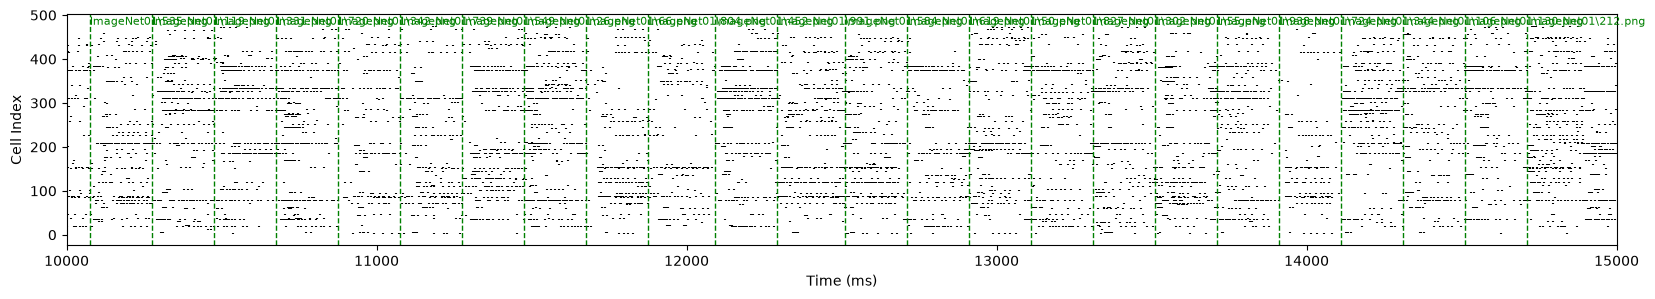

In [7]:
# Plot spike times for all cells and image onsets
d_stim = sb.stim_data

# Selecting first epoch and a time range
epoch_idx = 0
t_min = 10000
t_max = 15000

f, ax = plt.subplots(1, 1, figsize=(20, 3))
n_cells = len(rb.cell_ids)
for cell_idx in range(n_cells):
    sts = rb.df_spike_times.at[cell_idx,'spike_times'][epoch_idx]
    sts = [t for t in sts if t_min <= t <= t_max]
    ax.eventplot(sts, lineoffsets=cell_idx, linelengths=0.5, color='k')

epoch_trials = np.where(d_stim['trial_epoch_idx'] == epoch_idx)[0]
for trial_idx in epoch_trials:
    img_onset_ms = d_stim['trial_onset_ms'][trial_idx]
    img_offset_ms = d_stim['trial_offset_ms'][trial_idx]
    if img_onset_ms < t_min or img_offset_ms > t_max:
        continue
    ax.axvline(x=img_onset_ms, color='g', linestyle='--', lw=1)
    img_path = d_stim['trial_image_paths'][trial_idx]
    ax.text(img_onset_ms, n_cells, img_path, fontsize=8, color='g')
    # ax.axvline(x=img_offset_ms, color='k', linestyle='--', lw=1)

ax.set_xlim(t_min, t_max)
ax.set_ylabel('Cell Index')
ax.set_xlabel('Time (ms)')

## Checking for consistency across repeats of a given image

IndexError: index 2 is out of bounds for axis 0 with size 2

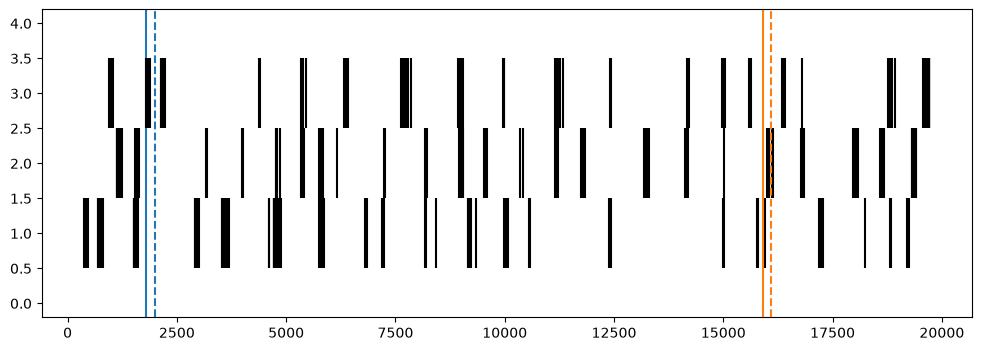

In [8]:
def consistency_check(cell_idx = 4, img_idx = 0):
    # Tracking image from first epoch
    img_path = sb.stim_data['all_image_paths'][0,img_idx]
    # print(img_path)

    img_trials = np.where(sb.stim_data['trial_image_paths'] == img_path)[0]
    img_epochs = sb.stim_data['trial_epoch_idx'][img_trials]

    img_onset_ms = sb.stim_data['trial_onset_ms'][img_trials]
    img_offset_ms = sb.stim_data['trial_offset_ms'][img_trials]

    # Plot spike times for example cell
    cell_idx = 4
    cell_id = rb.df_spike_times.at[cell_idx, 'cell_id']
    sts = rb.df_spike_times.at[cell_idx, 'spike_times']
    f, ax = plt.subplots(figsize=(12, 4))
    for i, st in enumerate(sts):
        ax.eventplot(st, lineoffsets=i + 1, colors='black')
        ax.axvline(img_onset_ms[i], color=f'C{i}')
        ax.axvline(img_offset_ms[i], color=f'C{i}', linestyle='--')
    ax.set_xlim(img_onset_ms[0] - 1000, img_onset_ms[0] + 3000)
    ax.set_title(f'Cell ID: {cell_id}\n{img_path}')

consistency_check(cell_idx=4, img_idx=8)

## Utility for splitting psth by image

In [9]:
bin_rate = 100
rb.bin_spike_times_at_rate(bin_rate, b_count=False)

Binning spikes for cells:   0%|          | 0/478 [00:00<?, ?it/s]

In [10]:
rb.bin_rate, rb.binned_spikes.shape

(100, (478, 50, 2050))

In [11]:
# Split into (cells, image trials, bins) xarray across all epochs
import xarray as xr
def split_psth_by_trials(sb, rb, pretime_ms=100, posttime_ms=400):
    # pretime_ms: time before image onset to include in the psth
    # posttime_ms: time after image onset to include in the psth
    d_stim = sb.stim_data
    bin_rate = rb.bin_rate
    binned_spikes = rb.binned_spikes
    
    n_cells = len(binned_spikes)
    n_trials = len(d_stim['trial_image_paths'])

    # Bins before and after image onset
    n_prebins = np.floor(pretime_ms / 1e3 * bin_rate).astype(int)
    n_postbins = np.floor(posttime_ms / 1e3 * bin_rate).astype(int)
    n_bins = n_prebins + n_postbins
    # print(f'n_prebins: {n_prebins}, n_postbins: {n_postbins}, n_bins: {n_bins}')

    # Initialize arrays
    split_psth = np.zeros((n_cells, n_trials, n_bins))
    deltas = []
    for i in range(n_trials):
        epoch_idx = d_stim['trial_epoch_idx'][i]
        
        onset_ms = d_stim['trial_onset_ms'][i]
        offset_ms = d_stim['trial_offset_ms'][i]
        onset_bin = np.round(onset_ms / 1e3* bin_rate).astype(int)
        offset_bin = np.round(offset_ms / 1e3 * bin_rate).astype(int)
        deltas.append(offset_bin - onset_bin)
        
        pre_bin_start = onset_bin - n_prebins
        post_bin_end = onset_bin + n_postbins
        
        if pre_bin_start < 0 or post_bin_end > len(binned_spikes[0, epoch_idx]):
            print(f'Skipping trial {i} due to out-of-bounds bin indices')
            continue
        snippet = binned_spikes[:, epoch_idx, pre_bin_start:post_bin_end]
        split_psth[:, i, :] = snippet
    
    # Take avg delta for offset
    n_duration_bins = np.mean(deltas)
    n_duration_bins = np.round(n_duration_bins).astype(int)
    n_duration_ms = n_duration_bins / bin_rate * 1e3
    print(f'Avg flash duration (bins): {n_duration_bins}, (ms): {n_duration_ms}')
    print(f'Variance duration across flashes: {np.var(deltas):.4f}')

    # Create xarray
    cell_ids = rb.cell_ids
    image_paths = d_stim['trial_image_paths']
    n_bin_dt = 1/bin_rate * 1000
    bin_edges = np.arange(-pretime_ms, posttime_ms, n_bin_dt)
    split_psth_xr = xr.DataArray(split_psth, coords=[cell_ids, image_paths, bin_edges], dims=['cell_id', 'image_path', 'time_ms'])
    # Add metadata for onset and offset times
    split_psth_xr.attrs['onset_ms'] = 0
    split_psth_xr.attrs['onset_bins'] = n_prebins
    offset_bins = n_prebins + n_duration_bins
    offset_ms = n_duration_ms
    split_psth_xr.attrs['offset_ms'] = offset_ms
    split_psth_xr.attrs['offset_bins'] = offset_bins
    return split_psth_xr

split_psth_xr = split_psth_by_trials(sb, rb)

Avg flash duration (bins): 20, (ms): 200.0
Variance duration across flashes: 0.2568


Text(0.5, 1.0, 'PSTH for cell 13')

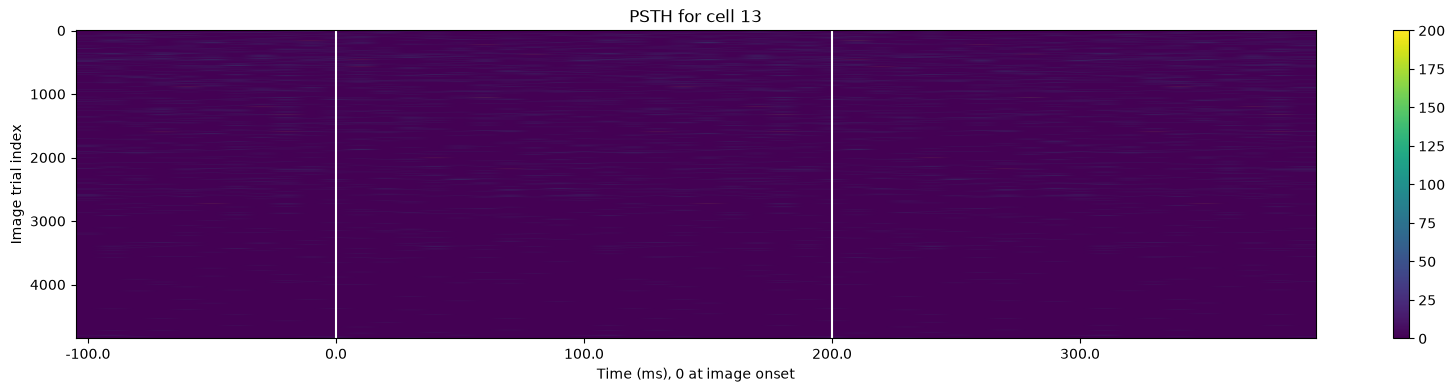

In [12]:
cell_id = rb.cell_ids[10]
plt.figure(figsize=(20, 4))
im=plt.imshow(split_psth_xr.sel(cell_id=cell_id), aspect='auto')
plt.colorbar(im)
plt.xticks(np.arange(0, len(split_psth_xr['time_ms']), 10), split_psth_xr['time_ms'].values[::10])
plt.axvline(x=split_psth_xr.attrs['onset_bins'], color='w')
plt.axvline(x=split_psth_xr.attrs['offset_bins'], color='w')

plt.xlabel('Time (ms), 0 at image onset')
plt.ylabel('Image trial index')
plt.title(f'PSTH for cell {cell_id}')

Text(0, 0.5, 'Firing rate (Hz)')

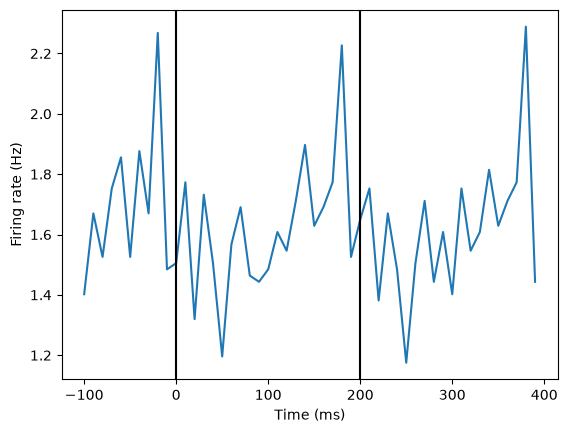

In [13]:
# Average psth across all images
time = split_psth_xr['time_ms'].values
plt.plot(time, split_psth_xr.sel(cell_id=cell_id).mean(dim='image_path'))
plt.axvline(split_psth_xr.attrs['onset_ms'], c='k')
plt.axvline(split_psth_xr.attrs['offset_ms'], c='k')
plt.xlabel('Time (ms)')
plt.ylabel('Firing rate (Hz)')